In [1]:
import json
import random
import torch
import torchvision
import torchvision.transforms as T
import torch.nn.functional as F
from torch.utils.data import DataLoader

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from models import MNIST_Net, CIFAR_Net

device = "cuda" if torch.cuda.is_available() else "cpu"
sns.set(style="whitegrid")

with open("./attack_success_rate.json", "r") as f:
    data = json.load(f)

In [2]:
def get_dataset_and_model(name):

    if name == "MNIST":
        dataset = torchvision.datasets.MNIST(
            root="./data", train=False, download=True, transform=T.ToTensor()
        )
        model = MNIST_Net().to(device)
        model.load_state_dict(torch.load("./ckpt/mnist.pth", map_location=device))
        model.eval()

    elif name == "CIFAR10":
        dataset = torchvision.datasets.CIFAR10(
            root="./data", train=False, download=True, transform=T.ToTensor()
        )
        model = CIFAR_Net().to(device)
        model.load_state_dict(torch.load("./ckpt/cifar.pth", map_location=device))
        model.eval()

    return dataset, model

In [3]:
rows = []

for d in data:
    for attack in ["FGSM Targeted", "FGSM Untargeted", "PGD Targeted", "PGD Untargeted"]:
        rows.append({
            "dataset": d["dataset"],
            "loss": d["loss_func"],
            "eps": d["eps"],
            "attack": attack,
            "attack_success_rate": d[attack]
        })

df = pd.DataFrame(rows)

df["attack_type"] = df["attack"].apply(lambda x: "Targeted" if "Targeted" in x else "Untargeted")
df["method"] = df["attack"].apply(lambda x: "FGSM" if "FGSM" in x else "PGD")

df = df.sort_values(by="eps")

df.head()

,dataset,loss,eps,attack,attack_success_rate,attack_type,method
16,mnist,kl,0.0001,FGSM Targeted,0.004531,Targeted,FGSM
17,mnist,kl,0.0001,FGSM Untargeted,0.034531,Untargeted,FGSM
18,mnist,kl,0.0001,PGD Targeted,0.004219,Targeted,PGD
19,mnist,kl,0.0001,PGD Untargeted,0.034531,Untargeted,PGD
20,cifar10,kl,0.0001,FGSM Targeted,0.034688,Targeted,FGSM


In [4]:
def compute_gradient_norm(model, x, y, loss_type):
    x = x.clone().detach().to(device)
    x.requires_grad = True
    y = y.to(device)

    logits = model(x)

    if loss_type == "ce":
        loss = F.cross_entropy(logits, y)

    elif loss_type == "mse":
        one_hot = F.one_hot(y, num_classes=logits.shape[1]).float()
        loss = F.mse_loss(F.softmax(logits, dim=1), one_hot)

    elif loss_type == "kl":
        one_hot = F.one_hot(y, num_classes=logits.shape[1]).float()
        loss = F.kl_div(F.log_softmax(logits, dim=1), one_hot, reduction="batchmean")

    elif loss_type == "margin":
        correct = logits.gather(1, y.unsqueeze(1)).squeeze()
        wrong = logits.topk(2, dim=1).values[:, 1]
        loss = -(correct - wrong).mean()

    loss.backward()
    return x.grad.abs().mean().item()

## MNIST

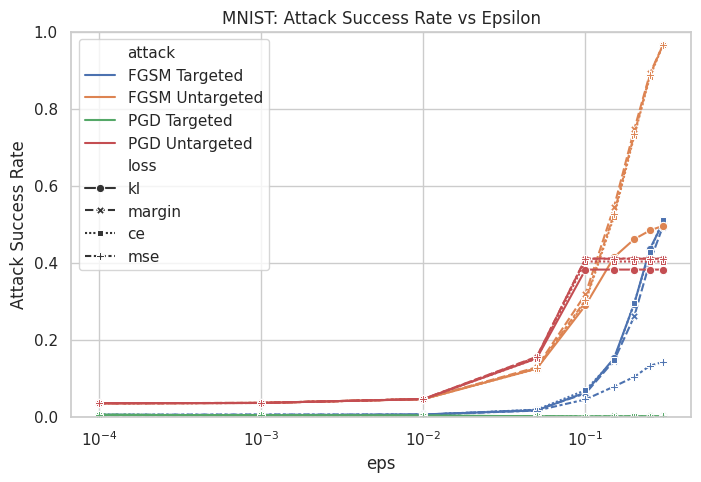

In [5]:
mnist_df = df[df["dataset"] == "mnist"]

plt.figure(figsize=(8,5))
sns.lineplot(
    data=mnist_df,
    x="eps",
    y="attack_success_rate",
    hue="attack",
    style="loss",
    markers=True
)
plt.xscale("log")
plt.ylim(0,1)
plt.title("MNIST: Attack Success Rate vs Epsilon")
plt.ylabel("Attack Success Rate")
plt.show()

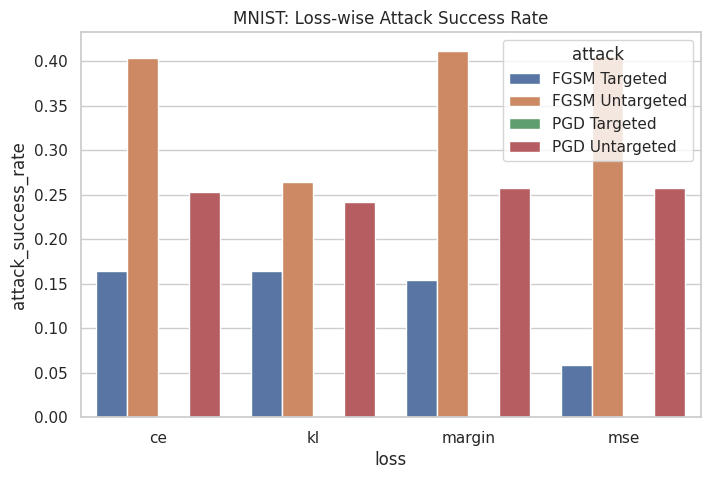

In [6]:
mnist_group = mnist_df.groupby(["loss", "attack"])["attack_success_rate"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=mnist_group, x="loss", y="attack_success_rate", hue="attack")
plt.title("MNIST: Loss-wise Attack Success Rate")
plt.show()

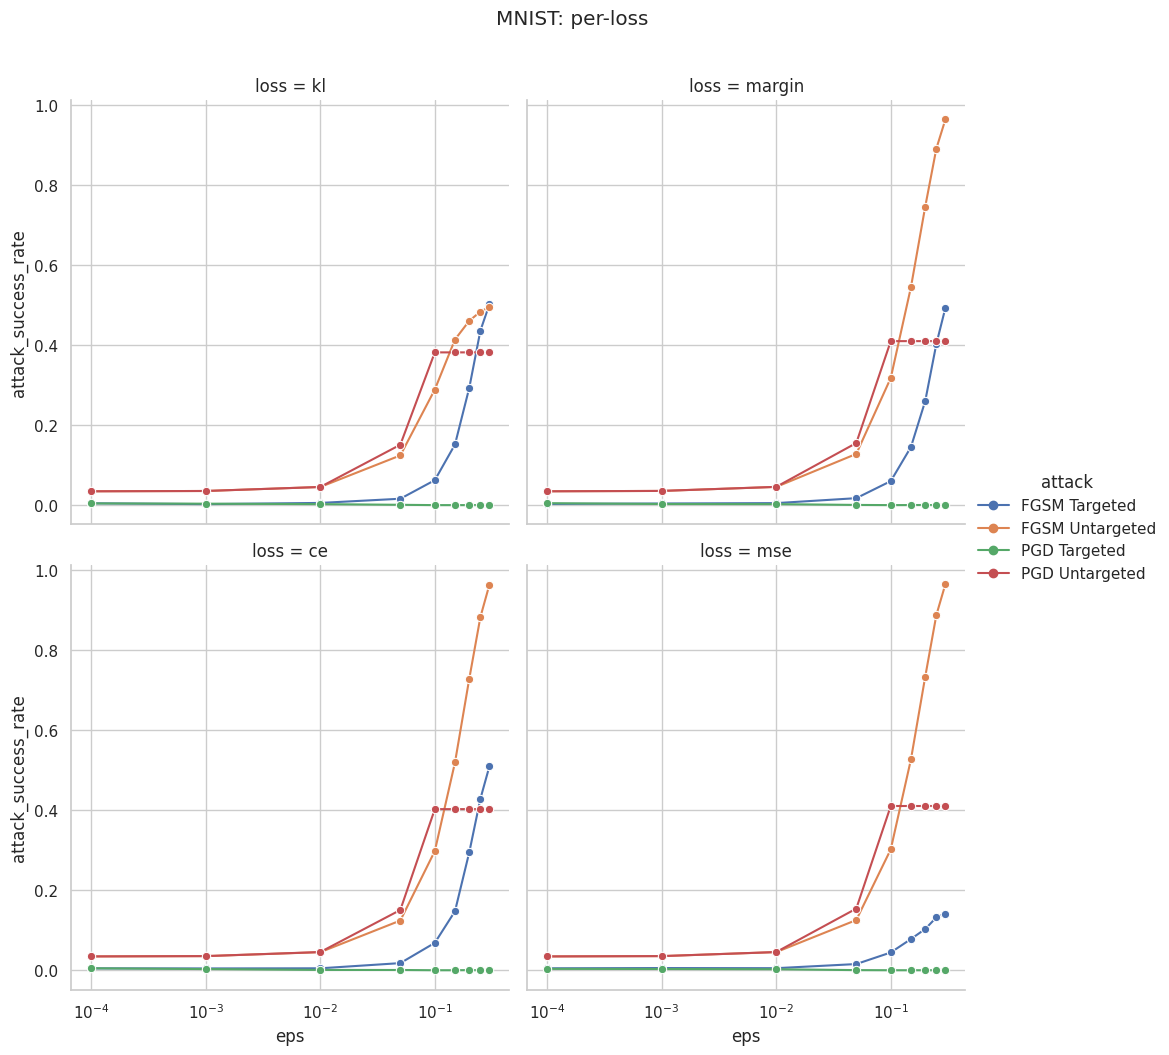

In [7]:
g = sns.relplot(
    data=mnist_df,
    x="eps",
    y="attack_success_rate",
    hue="attack",
    col="loss",
    kind="line",
    marker="o",
    col_wrap=2
)
g.set(xscale="log")
g.fig.suptitle("MNIST: per-loss", y=1.05)
plt.show()

In [8]:
dataset, model = get_dataset_and_model("MNIST")
loader = DataLoader(dataset, batch_size=128, shuffle=False)

grad_results = []

for loss_name in ["ce", "mse", "kl", "margin"]:
    grads = []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        model.zero_grad()
        grads.append(compute_gradient_norm(model, x, y, loss_name))

    grad_results.append({
        "loss": loss_name,
        "grad_norm": sum(grads)/len(grads)
    })

mnist_grad_df = pd.DataFrame(grad_results)

sns.barplot(data=mnist_grad_df, x="loss", y="grad_norm")
plt.title("MNIST Gradient Magnitude (Full)")
plt.show()

## CIFAR10

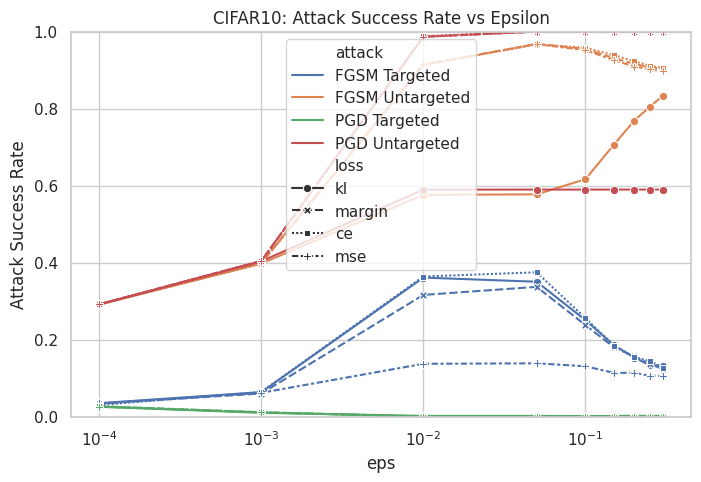

In [9]:
cifar_df = df[df["dataset"] == "cifar10"]

plt.figure(figsize=(8,5))
sns.lineplot(
    data=cifar_df,
    x="eps",
    y="attack_success_rate",
    hue="attack",
    style="loss",
    markers=True
)
plt.xscale("log")
plt.ylim(0,1)
plt.title("CIFAR10: Attack Success Rate vs Epsilon")
plt.ylabel("Attack Success Rate")
plt.show()

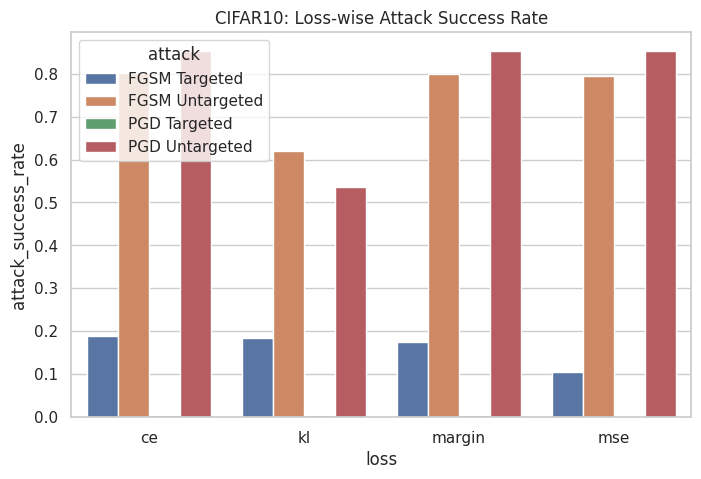

In [10]:
cifar_group = cifar_df.groupby(["loss", "attack"])["attack_success_rate"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=cifar_group, x="loss", y="attack_success_rate", hue="attack")
plt.title("CIFAR10: Loss-wise Attack Success Rate")
plt.show()

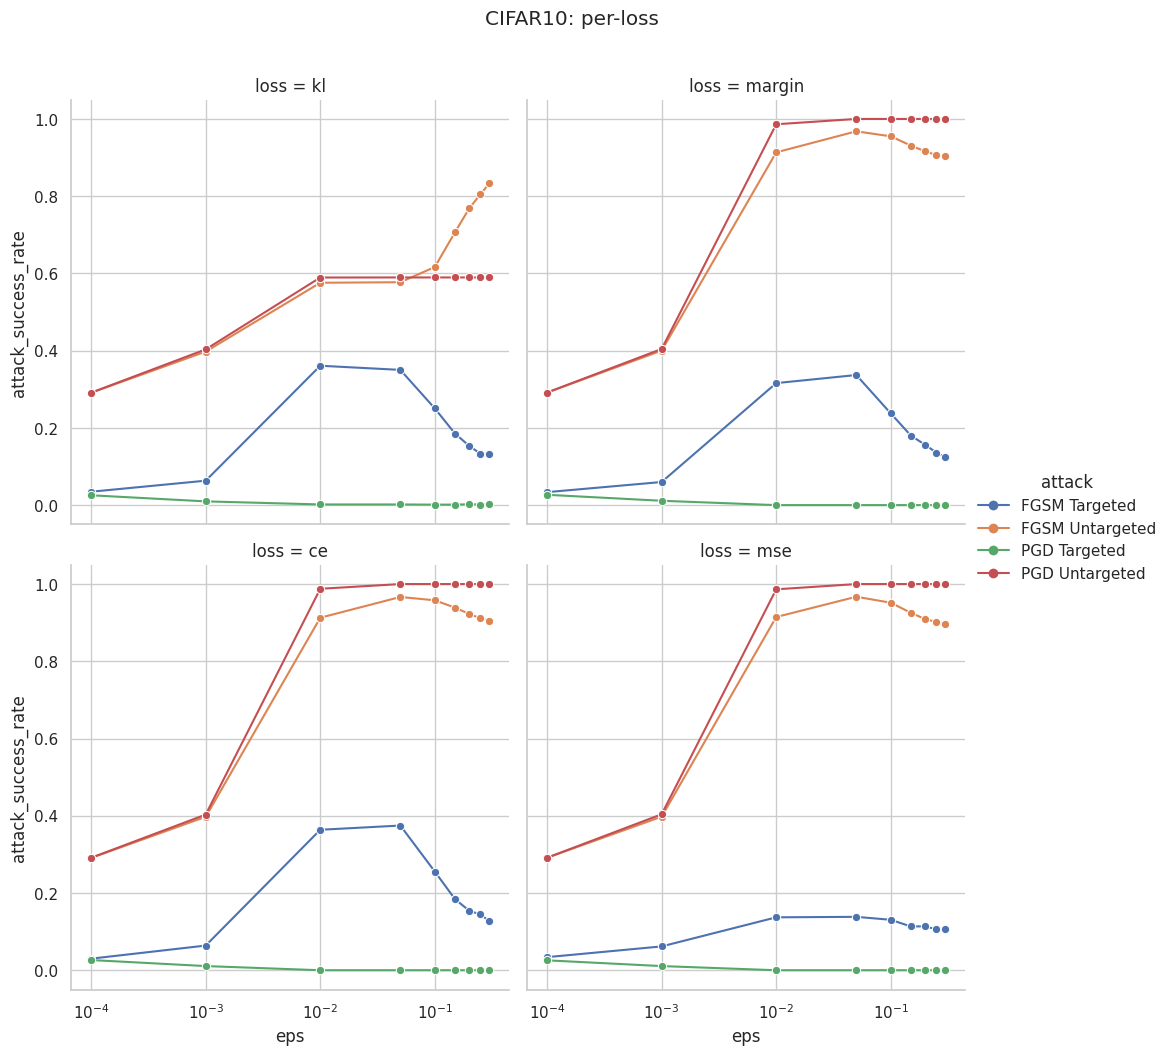

In [11]:
g = sns.relplot(
    data=cifar_df,
    x="eps",
    y="attack_success_rate",
    hue="attack",
    col="loss",
    kind="line",
    marker="o",
    col_wrap=2
)
g.set(xscale="log")
g.fig.suptitle("CIFAR10: per-loss", y=1.05)
plt.show()

Files already downloaded and verified


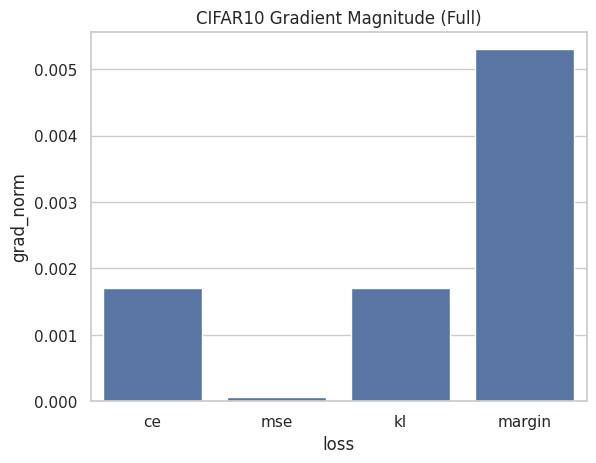

In [12]:
dataset, model = get_dataset_and_model("CIFAR10")
loader = DataLoader(dataset, batch_size=128, shuffle=False)

grad_results = []

for loss_name in ["ce", "mse", "kl", "margin"]:
    grads = []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        model.zero_grad()
        grads.append(compute_gradient_norm(model, x, y, loss_name))

    grad_results.append({
        "loss": loss_name,
        "grad_norm": sum(grads)/len(grads)
    })

cifar_grad_df = pd.DataFrame(grad_results)

sns.barplot(data=cifar_grad_df, x="loss", y="grad_norm")
plt.title("CIFAR10 Gradient Magnitude (Full)")
plt.show()